In [1]:
from rabtracks import *
sns.set_context("paper")

In [2]:
def plot_intensity_without_track(TRACK):
    fig, axs = plt.subplots(3, sharex = True, figsize = cm2inch([10,10]),)
    
    # Pressure
    for s in TRACK.source.values:
        if s == "IBTrACS":
            TRACK.wmo_pres.plot(ax = axs[0], color = PALETTE[s], lw = 3, label = s)
        else:
            TRACK.sel(source = s).pres.plot(ax = axs[0], color = PALETTE[s], label = s)
    axs[0].set_ylabel("SLP\nhPa")
    
    # Wind
    for s in TRACK.source.values:
        if s == "IBTrACS":
            TRACK.wmo_wind.plot(ax = axs[1], color = PALETTE[s], lw = 3)
        else:
            TRACK.sel(source = s).wind10.plot(ax = axs[1], color = PALETTE[s],)
    axs[1].set_ylim(0)
    axs[1].set_ylabel("Wind\nm/s")
    
    # Vorticity
    for s in TRACK.source.values:
        TRACK.sel(source = s).vo850.plot(ax = axs[2], color = PALETTE[s],)
    axs[2].set_ylim(0)
    axs[2].set_ylabel("Vorticity\n$10^{-5}s^{-1}$")
    
    for ax in axs:
        #ax.set_title('')
        ax.set_xlabel('')
        ax.grid()
        ax.set_title('')

    axs[-1].xaxis.set_major_formatter(DateFormatter('%d/%m'))
    axs[-1].xaxis.set_major_locator(DayLocator(interval=6))

    NAME = TRACK.name.values[0]
    SEASON = TRACK.time.dt.year.values[0]
    fig.suptitle(NAME + ' ('+str(SEASON)+')')
    plt.tight_layout()
    fig.legend(*axs[0].get_legend_handles_labels(), 
               loc = "outside upper center", ncol = 2, bbox_to_anchor = (0.51,0.03))

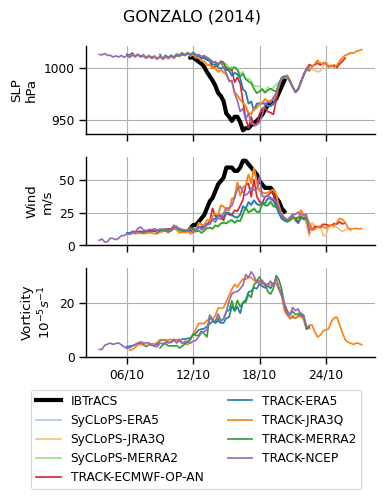

In [3]:
b = "NA"
eib = xr.open_dataset("../RABTracks/RABTracks_"+b+".nc")
NAME, SEASON = "GONZALO", 2014
TRACK = eib.where((eib.name == NAME) & (eib.time.dt.year == SEASON), drop = True)
TRACK = TRACK.set_coords("time").swap_dims({"record":"time"})
plot_intensity_without_track(TRACK)
sns.despine()

In [7]:
def plot_intensity_with_track(TRACK):
    fig = plt.figure(figsize=cm2inch([10, 13]))
    gs = fig.add_gridspec(4, 1, height_ratios=[1.5, 1, 1, 1])

    # Top panel: track map
    ax_map = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())
    for s in TRACK.source.values:
        K = TRACK.sel(source=s).squeeze()
        if (~np.isnan(K.lon)).sum() > 0:
            mask = ~np.isnan(K.lon) & ~np.isnan(K.lat)
            lon = K.lon[mask]
            lat = K.lat[mask]
            lw = 5 if s == 'IBTrACS' else None
            ax_map.plot(lon, lat, color=PALETTE[s], lw=lw, label=s,
                        transform=ccrs.PlateCarree())
    ax_map.coastlines(color="grey")

    # Remaining panels: pressure, wind, vorticity
    axs = [fig.add_subplot(gs[i]) for i in range(1, 4)]
    axs[1].sharex(axs[0])
    axs[2].sharex(axs[0])

    # Pressure
    for s in TRACK.source.values:
        if s == "IBTrACS":
            TRACK.wmo_pres.plot(ax=axs[0], color=PALETTE[s], lw=3, label=s)
        else:
            TRACK.sel(source=s).pres.plot(ax=axs[0], color=PALETTE[s], label=s)
    axs[0].set_ylabel("SLP\nhPa")

    # Wind
    for s in TRACK.source.values:
        if s == "IBTrACS":
            TRACK.wmo_wind.plot(ax=axs[1], color=PALETTE[s], lw=3)
        else:
            TRACK.sel(source=s).wind10.plot(ax=axs[1], color=PALETTE[s])
    axs[1].set_ylim(0)
    axs[1].set_ylabel("Wind\nm/s")

    # Vorticity
    for s in TRACK.source.values:
        TRACK.sel(source=s).vo850.plot(ax=axs[2], color=PALETTE[s])
    axs[2].set_ylim(0)
    axs[2].set_ylabel("Vorticity\n$10^{-5}s^{-1}$")

    for ax in axs:
        ax.set_xlabel('')
        ax.grid()
        ax.set_title('')

    axs[-1].xaxis.set_major_formatter(DateFormatter('%d/%m'))
    axs[-1].xaxis.set_major_locator(DayLocator(interval=6))

    NAME = TRACK.name.values[0]
    SEASON = TRACK.time.dt.year.values[0]
    fig.suptitle(NAME + ' (' + str(SEASON) + ')')
    plt.tight_layout()
    fig.legend(*axs[0].get_legend_handles_labels(),
               loc="outside upper center", ncol=2, bbox_to_anchor=(0.51, 0.03))

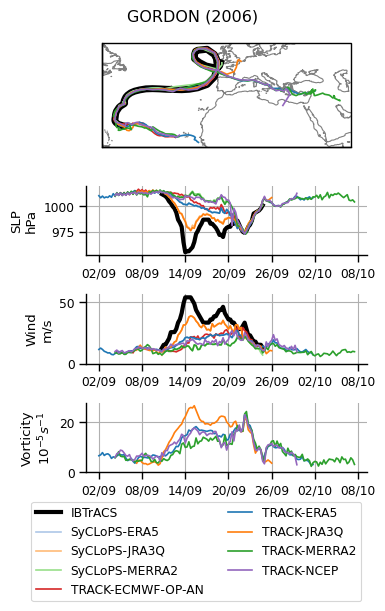

In [9]:
b = "NA"
eib = xr.open_dataset("../RABTracks/RABTracks_"+b+".nc")
NAME, SEASON = "GORDON", 2006
TRACK = eib.where((eib.name == NAME) & (eib.time.dt.year == SEASON), drop = True)
TRACK = TRACK.set_coords("time").swap_dims({"record":"time"})
plot_intensity_with_track(TRACK)
sns.despine()

plt.savefig("intensity_info.png", bbox_inches = "tight")
plt.savefig("intensity_info.pdf", bbox_inches = "tight")

In [11]:
def plot_info(TRACK):
    fig, axs = plt.subplots(7, sharex = True, figsize = cm2inch([18,22]), 
                            height_ratios = [1,1,1,0.3,0.3,0.3,0.3])
    
    # Pressure
    for s in TRACK.source.values:
        if s == "IBTrACS":
            TRACK.wmo_pres.plot(ax = axs[0], color = PALETTE[s], lw = 3, label = s)
        else:
            TRACK.sel(source = s).pres.plot(ax = axs[0], color = PALETTE[s], label = s)
    axs[0].set_ylabel("SLP\nhPa")
    
    # Wind
    for s in TRACK.source.values:
        if s == "IBTrACS":
            TRACK.wmo_wind.plot(ax = axs[1], color = PALETTE[s], lw = 3)
        else:
            TRACK.sel(source = s).wind10.plot(ax = axs[1], color = PALETTE[s],)
    axs[1].set_ylim(0)
    axs[1].set_ylabel("Wind\nm/s")
    
    # Vorticity
    for s in TRACK.source.values:
        TRACK.sel(source = s).vo850.plot(ax = axs[2], color = PALETTE[s],)
    axs[2].set_ylim(0)
    axs[2].set_ylabel("Vorticity\n$10^{-5}s^{-1}$")
    
    # Label + IBTrACS nature
    plot_categorical(axs[3], TRACK.time.values, TRACK.nature.values,)
    axs[3].set_ylabel("IBTrACS\nnature", rotation = 0, labelpad = 50, loc = "bottom")
    
    for i, s in enumerate([s.values for s in TRACK.source if s.str.startswith("SyCLoPS")]):
        plot_categorical(axs[4+i], TRACK.time.values, TRACK.sel(source = s).label.astype(str).values)
        axs[4+i].set_title(s, style = "italic", size = "medium")
    axs[5].set_ylabel("SyCLoPS labels", size = "large")
    
    # Size
    #for s in TRACK.source.values:
    #    TRACK.sel(source = s).lpsarea.plot(ax = axs[-1], color = PALETTE[s],)
    #axs[-1].set_ylabel("LPS Area\nkm$^{2}$")
    
    #TRACK.bom_rmw.plot(ax = axs[-1], color = "k",)
    #ax2 = axs[-1].twinx()
    #TRACK.usa_roci.plot(ax = ax2, color = "k", linestyle = "--", label = "ROCI")
    #TRACK.usa_rmw.plot(ax = ax2, color = "k", linestyle = "--", label = "RMW")
    #ax2.set_ylabel("ROCI\nkm")
    #ax2.legend()
    
    for ax in axs:
        #ax.set_title('')
        ax.set_xlabel('')
        ax.grid()
    for i in [0,1,2,3,-1]:
        axs[i].set_title('')

    NAME = TRACK.name.values[0]
    SEASON = TRACK.time.dt.year.values[0]
    fig.suptitle(NAME + ' ('+str(SEASON)+')')
    plt.tight_layout()
    fig.legend(*axs[0].get_legend_handles_labels(), 
               loc = "outside lower center", ncol = 3, bbox_to_anchor = (0.5,-0.08))
    fig.legend(*axs[3].get_legend_handles_labels(), title = "IBTrACS labels",
               loc = "outside upper left", ncol = 2, bbox_to_anchor = (0.1,-0.08))
    fig.legend(*axs[4].get_legend_handles_labels(), title = "SyCLoPS labels",
               loc = "outside upper right", ncol = 4, bbox_to_anchor = (0.9, -0.08))

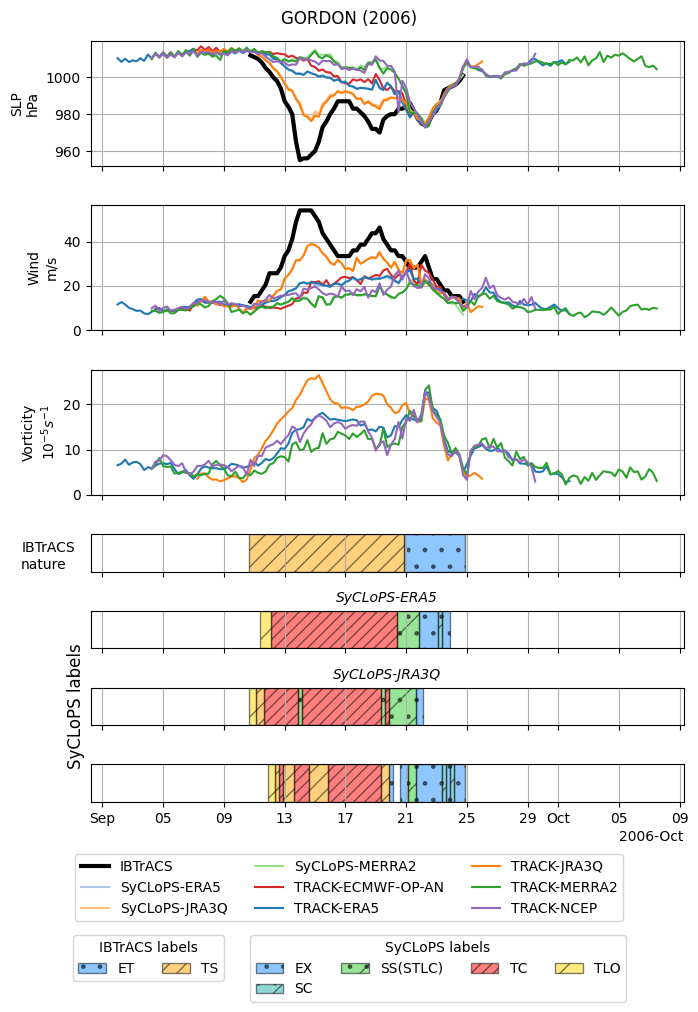

In [12]:
b = "NA"
eib = xr.open_dataset("../RABTracks/RABTracks_"+b+".nc")
NAME, SEASON = "GORDON", 2006
TRACK = eib.where((eib.name == NAME) & (eib.time.dt.year == SEASON), drop = True)
TRACK = TRACK.set_coords("time").swap_dims({"record":"time"})
plot_info(TRACK)

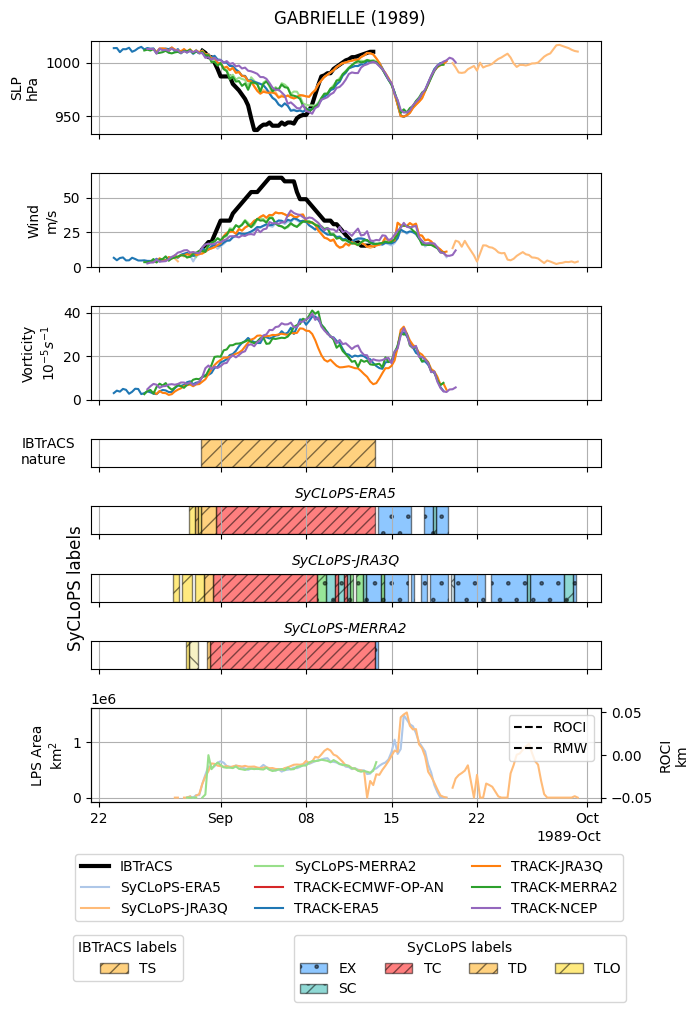

In [8]:
NAME, SEASON = "GABRIELLE", 1989
TRACK = eib.where((eib.name == NAME) & (eib.time.dt.year == SEASON), drop = True)
TRACK = TRACK.set_coords("time").swap_dims({"record":"time"})
plot_info(TRACK)